In [1]:
import pandas as pd
import numpy as np
import re
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [2]:
train_df = pd.read_csv(r"C:\Users\Pritika\OneDrive\LSTM\imdb_regression_train.csv")
test_df = pd.read_csv(r"C:\Users\Pritika\OneDrive\LSTM\imdb_regression_test.csv")

print(train_df.shape, test_df.shape)
train_df.head()

(25000, 2) (25000, 2)


,text,rating
0,Bromwell High is a cartoon comedy. It ran at t...,9
1,Homelessness (or Houselessness as George Carli...,8
2,Brilliant over-acting by Lesley Ann Warren. Be...,10
3,This is easily the most underrated film inn th...,7
4,This is not the typical Mel Brooks film. It wa...,8


In [3]:
def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)          # remove HTML tags like <br />
    text = re.sub(r"[^a-zA-Z']", ' ', text)      # keep only letters and apostrophes
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['clean_text'] = train_df['text'].apply(clean_text)
test_df['clean_text'] = test_df['text'].apply(clean_text)

train_df[['text', 'clean_text']].head(2)

,text,clean_text
0,Bromwell High is a cartoon comedy. It ran at t...,bromwell high is a cartoon comedy it ran at th...
1,Homelessness (or Houselessness as George Carli...,homelessness or houselessness as george carlin...


In [4]:
def tokenize(text):
    return text.split()

train_df['tokens'] = train_df['clean_text'].apply(tokenize)
test_df['tokens'] = test_df['clean_text'].apply(tokenize)

all_tokens = [tok for tokens in train_df['tokens'] for tok in tokens]
counter = Counter(all_tokens)

VOCAB_SIZE = 20000
most_common = counter.most_common(VOCAB_SIZE - 2)   # reserve 0=PAD, 1=UNK

word2idx = {'<PAD>': 0, '<UNK>': 1}
for word, _ in most_common:
    word2idx[word] = len(word2idx)

print("Vocab size:", len(word2idx))

Vocab size: 20000


In [5]:
MAX_LEN = 200

def encode(tokens):
    ids = [word2idx.get(tok, 1) for tok in tokens]
    if len(ids) < MAX_LEN:
        ids = ids + [0] * (MAX_LEN - len(ids))
    else:
        ids = ids[:MAX_LEN]
    return ids

train_df['encoded'] = train_df['tokens'].apply(encode)
test_df['encoded'] = test_df['tokens'].apply(encode)

In [7]:
GLOVE_PATH = r"C:\Users\Pritika\OneDrive\LSTM\glove.2024.wikigiga.100d\wiki_giga_2024_100_MFT20_vectors_seed_2024_alpha_0.75_eta_0.05.050_combined.txt"
EMBED_DIM = 100

embeddings_index = {}
skipped = 0

with open(GLOVE_PATH, encoding='utf8') as f:
    first_line = f.readline()
    parts = first_line.split()

    if len(parts) == 2 and parts[0].isdigit() and parts[1].isdigit():
        print("Header detected, skipping first line:", first_line.strip())
    else:
        try:
            word = parts[0]
            vector = np.asarray(parts[1:], dtype='float32')
            if len(vector) == EMBED_DIM:
                embeddings_index[word] = vector
        except ValueError:
            skipped += 1

    for line in f:
        values = line.split()
        if len(values) != EMBED_DIM + 1:
            skipped += 1
            continue
        word = values[0]
        try:
            vector = np.asarray(values[1:], dtype='float32')
        except ValueError:
            skipped += 1
            continue
        embeddings_index[word] = vector

print("Loaded word vectors:", len(embeddings_index))
print("Skipped malformed lines:", skipped)

embedding_matrix = np.zeros((len(word2idx), EMBED_DIM))
found = 0
for word, idx in word2idx.items():
    if word in embeddings_index:
        embedding_matrix[idx] = embeddings_index[word]
        found += 1

embedding_matrix = torch.tensor(embedding_matrix, dtype=torch.float32)
print("Embedding matrix shape:", embedding_matrix.shape)
print(f"Words found in GloVe: {found}/{len(word2idx)}")

Loaded word vectors: 1287614
Skipped malformed lines: 3533
Embedding matrix shape: torch.Size([20000, 100])
Words found in GloVe: 19234/20000


In [8]:
class IMDBDataset(Dataset):
    def __init__(self, encoded_texts, ratings):
        self.X = torch.tensor(list(encoded_texts), dtype=torch.long)
        self.y = torch.tensor(ratings.values, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_texts, val_texts, train_ratings, val_ratings = train_test_split(
    train_df['encoded'], train_df['rating'], test_size=0.1, random_state=42
)

train_dataset = IMDBDataset(train_texts, train_ratings)
val_dataset = IMDBDataset(val_texts, val_ratings)
test_dataset = IMDBDataset(test_df['encoded'], test_df['rating'])

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [9]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 2, 1)

    def forward(self, lstm_out):
        # lstm_out: [batch, seq_len, hidden*2]
        scores = self.attn(lstm_out).squeeze(-1)          # [batch, seq_len]
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)  # [batch, seq_len, 1]
        context = torch.sum(lstm_out * weights, dim=1)    # [batch, hidden*2]
        return context, weights

class BiLSTMAttentionRegressor(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim=128, num_layers=1, dropout=0.3):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=False, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                             batch_first=True, bidirectional=True, dropout=0.0)
        self.attention = Attention(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim * 2, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        embedded = self.embedding(x)                  # [batch, seq_len, embed_dim]
        lstm_out, _ = self.lstm(embedded)              # [batch, seq_len, hidden*2]
        context, attn_weights = self.attention(lstm_out)
        x = self.dropout(context)
        x = self.relu(self.fc1(x))
        out = self.fc2(x)
        return out.squeeze(-1), attn_weights

model = BiLSTMAttentionRegressor(embedding_matrix).to(device)
print(model)

BiLSTMAttentionRegressor(
  (embedding): Embedding(20000, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True, bidirectional=True)
  (attention): Attention(
    (attn): Linear(in_features=256, out_features=1, bias=True)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=256, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)


In [10]:
import os
torch.set_num_threads(os.cpu_count())
print("Using", os.cpu_count(), "CPU threads")

Using 16 CPU threads


In [11]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 10
PATIENCE = 2   # stop if val loss doesn't improve for 2 epochs in a row

train_losses, val_losses = [], []
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds, _ = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
    train_loss = total_loss / len(train_dataset)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds, _ = model(X_batch)
            loss = criterion(preds, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    val_loss = val_loss / len(val_dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict()   # save best version
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(best_model_state)   # restore best weights before eval

Epoch 1/10 | Train Loss: 10.0579 | Val Loss: 4.7772
Epoch 2/10 | Train Loss: 4.1207 | Val Loss: 4.2617
Epoch 3/10 | Train Loss: 3.1540 | Val Loss: 3.9383
Epoch 4/10 | Train Loss: 2.3649 | Val Loss: 3.9723
Epoch 5/10 | Train Loss: 1.8190 | Val Loss: 4.3188
Early stopping at epoch 5


<All keys matched successfully>

In [12]:
model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds, _ = model(X_batch)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_true = np.array(all_true)

mse = mean_squared_error(all_true, all_preds)
mae = mean_absolute_error(all_true, all_preds)
r2 = r2_score(all_true, all_preds)

print(f"Test MSE: {mse:.4f}")
print(f"Test MAE: {mae:.4f}")
print(f"Test R2: {r2:.4f}")

Test MSE: 4.8040
Test MAE: 1.5477
Test R2: 0.6058


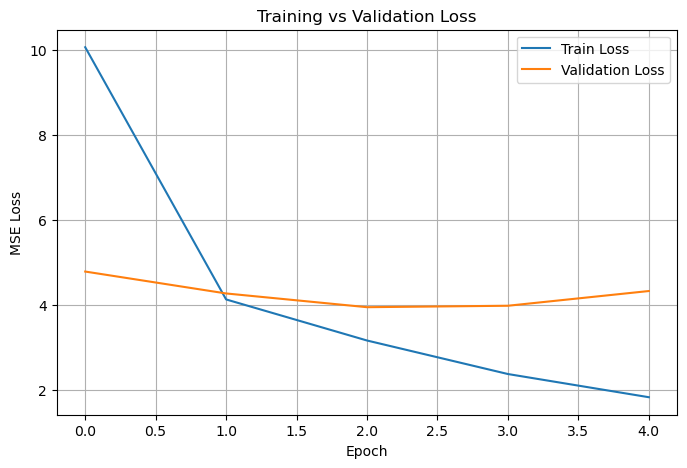

In [13]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

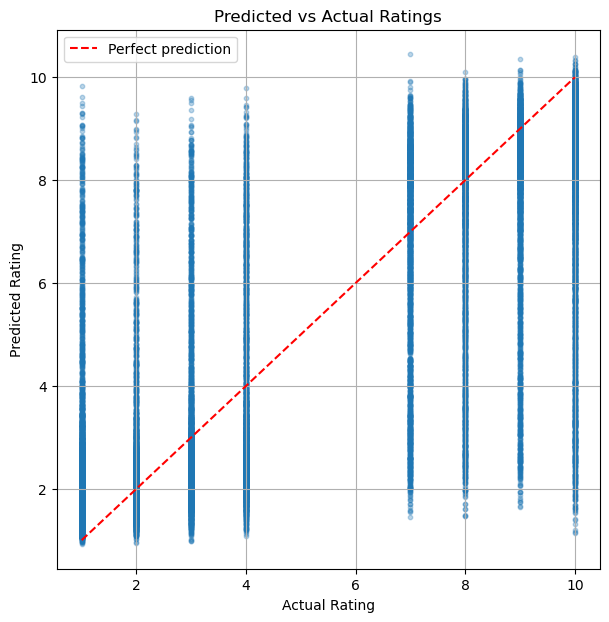

In [14]:
plt.figure(figsize=(7,7))
plt.scatter(all_true, all_preds, alpha=0.3, s=10)
plt.plot([1,10],[1,10], 'r--', label='Perfect prediction')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Predicted vs Actual Ratings')
plt.legend()
plt.grid(True)
plt.show()

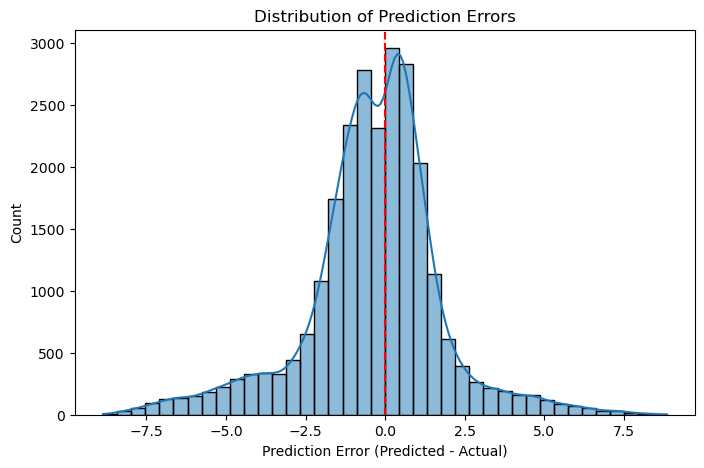

In [15]:
errors = all_preds - all_true

plt.figure(figsize=(8,5))
sns.histplot(errors, bins=40, kde=True)
plt.xlabel('Prediction Error (Predicted - Actual)')
plt.title('Distribution of Prediction Errors')
plt.axvline(0, color='red', linestyle='--')
plt.show()

In [18]:
# Error analysis: worst predictions often involve sarcasm/irony,
# where positive words are used to describe a poorly-rated movie
# (or vice versa). Word embeddings capture word-level sentiment
# but not tone, so the model misreads these cases.

test_df_results = test_df.copy()
test_df_results['predicted'] = all_preds
test_df_results['error'] = np.abs(all_preds - all_true)

worst_cases = test_df_results.sort_values('error', ascending=False).head(10)

for i, row in worst_cases.iterrows():
    print(f"Actual: {row['rating']} | Predicted: {row['predicted']:.2f} | Error: {row['error']:.2f}")
    print(row['text'][:300], "...\n")

print("Note: Most large errors above involve sarcasm/irony — positive language")
print("used for a badly-rated movie (or negative language for a good one).")
print("The model can't detect this since GloVe embeddings capture word-level")
print("sentiment, not tone or intent.")

Actual: 10 | Predicted: 1.13 | Error: 8.87
.....whoops - looks like it's gonna cost you a whopping £198.00 to buy a copy (either DVD or Video format)from ITV direct.<br /><br />Ouch.<br /><br />Sorry about this, but IMDB won't let me submit this comment unless it has at least 10 lines, so...........<br /><br />blahblahblahblahblahblahblahbla ...

Actual: 10 | Predicted: 1.16 | Error: 8.84
I have no idea why everyone hates this movie to call it garbage a travesty an unexceptable sequel is just unfair i mean what else could they have made for a sequel then. Cause seriously I think it should have had a sequel (Rodney Dangerfield) says: hey everyone were all going to get laid and then a  ...

Actual: 1 | Predicted: 9.83 | Error: 8.83
This movie was pure genius. John Waters is brilliant. It is hilarious and I am not sick of it even after seeing it about 20 times since I bought it a few months ago. The acting is great, although Ricki Lake could have been better. And Johnny Depp is magnificen

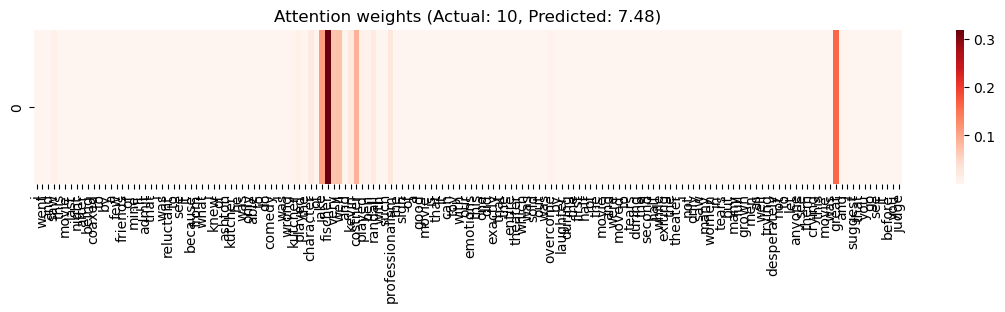

In [19]:
sample_idx = 0
X_sample = torch.tensor([test_df['encoded'].iloc[sample_idx]]).to(device)
with torch.no_grad():
    pred, attn_weights = model(X_sample)

tokens = test_df['tokens'].iloc[sample_idx][:MAX_LEN]
weights = attn_weights.cpu().numpy().squeeze()[:len(tokens)]

plt.figure(figsize=(14,2))
sns.heatmap([weights], xticklabels=tokens, cmap='Reds', cbar=True)
plt.title(f"Attention weights (Actual: {test_df['rating'].iloc[sample_idx]}, Predicted: {pred.item():.2f})")
plt.xticks(rotation=90)
plt.show()